# Cell 0 (Markdown)
## Stage 7 — RAG-Assisted Caption Refinement (No Retraining)

Goal:
- Use retrieval over training captions to refine already-generated captions.
- Compare baseline vs RAG using BLEU-1 and BLEU-4.
- Save all outputs to `artifacts/stage7/`.


In [12]:
# GPU check for Stage 7 (TensorFlow inference)
import time
import subprocess
import tensorflow as tf

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("Physical GPUs:", gpus)

if len(gpus) == 0:
    raise RuntimeError("No GPU detected. For model inference, switch to a GPU runtime.")

# Optional: safer memory behavior
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

print("Logical GPUs:", tf.config.list_logical_devices("GPU"))

# Real GPU compute test
with tf.device("/GPU:0"):
    a = tf.random.normal((2048, 2048))
    b = tf.random.normal((2048, 2048))
    t0 = time.time()
    c = tf.matmul(a, b)
    _ = c.numpy()  # sync
    dt = time.time() - t0

print("MatMul ran on:", c.device)
if "GPU" not in c.device.upper():
    raise RuntimeError(f"TensorFlow op did not run on GPU: {c.device}")

# Optional nvidia-smi check
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,utilization.gpu",
         "--format=csv,noheader,nounits"],
        text=True
    )
    print("nvidia-smi:\n", smi)
except Exception as e:
    print("nvidia-smi not available:", e)

print("GPU CHECK PASS ✅")
print("Note: TF-IDF / sklearn retrieval is CPU-bound; GPU is used for TensorFlow model inference.")


NotFoundError: dlopen(/opt/anaconda3/envs/drummin/lib/python3.11/site-packages/tensorflow-plugins/libmetal_plugin.dylib, 0x0006): Library not loaded: @rpath/_pywrap_tensorflow_internal.so
  Referenced from: <8B62586B-B082-3113-93AB-FD766A9960AE> /opt/anaconda3/envs/drummin/lib/python3.11/site-packages/tensorflow-plugins/libmetal_plugin.dylib
  Reason: tried: '/opt/anaconda3/envs/drummin/lib/python3.11/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/_pywrap_tensorflow_internal.so' (no such file), '/opt/anaconda3/envs/drummin/lib/python3.11/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/_pywrap_tensorflow_internal.so' (no such file), '/opt/anaconda3/envs/drummin/bin/../lib/_pywrap_tensorflow_internal.so' (no such file)

In [1]:
# Cell 1 — Setup
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
np.random.seed(SEED)

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/dannyyy/Downloads/accessops_coco_ai"),
]

def find_project_root():
    for c in CANDIDATE_ROOTS:
        if (c / "artifacts" / "captions_clean_with_splits.csv").exists():
            return c
    raise FileNotFoundError("Could not locate project root with artifacts/captions_clean_with_splits.csv")

PROJECT_ROOT = find_project_root()
ART_DIR = PROJECT_ROOT / "artifacts"
STAGE7_DIR = ART_DIR / "stage7"
STAGE7_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STAGE7_DIR:", STAGE7_DIR)


/opt/anaconda3/envs/drummin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /Users/dannyyy/Downloads/accessops_coco_ai
STAGE7_DIR: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7


In [3]:
# Cell 2 — Load base captions + references
CAPTIONS_CSV = ART_DIR / "captions_clean_with_splits.csv"

# Default source: stage6 predictions (full 2500). You can switch this path if needed.
BASE_CAPTION_CSV = ART_DIR / "stage6" / "reroute_predictions.csv"

assert CAPTIONS_CSV.exists(), f"Missing: {CAPTIONS_CSV}"
assert BASE_CAPTION_CSV.exists(), f"Missing: {BASE_CAPTION_CSV}"

caps_df = pd.read_csv(CAPTIONS_CSV)
pred_df = pd.read_csv(BASE_CAPTION_CSV)

# Figure out caption column name
if "caption" in pred_df.columns:
    pred_caption_col = "caption"
elif "generated_caption" in pred_df.columns:
    pred_caption_col = "generated_caption"
else:
    raise ValueError("No caption column found in BASE_CAPTION_CSV. Expected 'caption' or 'generated_caption'.")

# Confidence fallback if missing
if "confidence" not in pred_df.columns:
    pred_df["confidence"] = 0.5

# Build test references map (all refs per image)
test_caps = caps_df[caps_df["split"] == "test"].copy()
refs_map = (
    test_caps.groupby("image_name")["comment_clean"]
    .apply(lambda s: [x for x in s.tolist() if isinstance(x, str) and x.strip()])
    .to_dict()
)

base_df = pred_df[["image_name", pred_caption_col, "confidence"]].copy()
base_df = base_df.rename(columns={pred_caption_col: "base_caption"})
base_df["image_name"] = base_df["image_name"].astype(str)
base_df["base_caption"] = base_df["base_caption"].astype(str)
base_df["confidence"] = pd.to_numeric(base_df["confidence"], errors="coerce").fillna(0.5)
base_df = base_df.drop_duplicates("image_name").reset_index(drop=True)

# Keep only rows that exist in test references
base_df = base_df[base_df["image_name"].isin(refs_map)].reset_index(drop=True)

print("Base rows:", len(base_df))
print("Test refs images:", len(refs_map))
base_df.head(3)


Base rows: 2500
Test refs images: 2500


,image_name,base_caption,confidence
0,000000289594.jpg,a man is walking down the street with a cell p...,0.497802
1,000000289659.jpg,a giraffe standing next to a tree in a field,0.540593
2,000000289702.jpg,a dog is sitting on a table with a bottle of wine,0.395040


In [4]:
# Cell 3 — Text + BLEU helpers
TOKEN_RE = re.compile(r"[a-z0-9']+")
SF = SmoothingFunction().method1

def normalize_text(t: str) -> str:
    t = str(t).lower().strip()
    t = re.sub(r"\s+", " ", t)
    return t

def tokenize(t: str):
    t = normalize_text(t)
    toks = TOKEN_RE.findall(t)
    return toks if toks else ["<empty>"]

def bleu_scores_for_df(df: pd.DataFrame, caption_col: str, refs: dict):
    b1, b4 = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"BLEU {caption_col}"):
        img = str(row["image_name"])
        cand = tokenize(row[caption_col])
        ref_list = refs.get(img, [])
        ref_toks = [tokenize(r) for r in ref_list if isinstance(r, str) and r.strip()]
        if not ref_toks:
            continue
        b1.append(sentence_bleu(ref_toks, cand, weights=(1, 0, 0, 0), smoothing_function=SF))
        b4.append(sentence_bleu(ref_toks, cand, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=SF))
    return {
        "bleu1": float(np.mean(b1) if b1 else 0.0),
        "bleu4": float(np.mean(b4) if b4 else 0.0),
        "n_eval": int(len(b1)),
    }

def row_bleu4(caption: str, image_name: str, refs: dict):
    cand = tokenize(caption)
    ref_toks = [tokenize(r) for r in refs.get(str(image_name), []) if isinstance(r, str) and r.strip()]
    if not ref_toks:
        return np.nan
    return float(sentence_bleu(ref_toks, cand, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=SF))


In [5]:
# Cell 4 — Baseline BLEU (current source captions)
base_df["base_caption"] = base_df["base_caption"].map(normalize_text)
base_scores = bleu_scores_for_df(base_df, "base_caption", refs_map)

print("BASE BLEU-1:", round(base_scores["bleu1"], 4))
print("BASE BLEU-4:", round(base_scores["bleu4"], 4))
print("N eval:", base_scores["n_eval"])


BLEU base_caption: 100%|██████████| 2500/2500 [00:00<00:00, 5980.89it/s]

BASE BLEU-1: 0.6707
BASE BLEU-4: 0.2221
N eval: 2500


In [6]:
# Cell 5 — Build retrieval index from train captions
TRAIN_CAP_LIMIT = None   # use full train corpus; set e.g. 200000 if RAM/time becomes too heavy
TOPK = 5
MAX_FEATURES = 120000

train_caps = caps_df[caps_df["split"] == "train"]["comment_clean"].dropna().astype(str).map(normalize_text)
train_caps = train_caps[train_caps.str.len() > 0].drop_duplicates().reset_index(drop=True)

if TRAIN_CAP_LIMIT is not None and TRAIN_CAP_LIMIT < len(train_caps):
    train_caps = train_caps.sample(TRAIN_CAP_LIMIT, random_state=SEED).reset_index(drop=True)

print("Retrieval corpus size:", len(train_caps))

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=MAX_FEATURES,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_caps.tolist())
nn = NearestNeighbors(n_neighbors=TOPK, metric="cosine", algorithm="brute", n_jobs=-1)
nn.fit(X_train)

print("X_train shape:", X_train.shape)


Retrieval corpus size: 566169
X_train shape: (566169, 120000)


In [7]:
# Cell 6 — Retrieve top-k captions for each base caption
queries = base_df["base_caption"].tolist()
Q = vectorizer.transform(queries)

distances, indices = nn.kneighbors(Q, n_neighbors=TOPK, return_distance=True)
similarities = 1.0 - distances

retrieved_top1 = []
retrieved_sim_top1 = []
retrieved_topk_json = []
sim_topk_json = []

for i in range(len(base_df)):
    idxs = indices[i].tolist()
    sims = similarities[i].tolist()
    caps = [train_caps.iloc[j] for j in idxs]
    retrieved_top1.append(caps[0])
    retrieved_sim_top1.append(float(sims[0]))
    retrieved_topk_json.append(json.dumps(caps, ensure_ascii=False))
    sim_topk_json.append(json.dumps([float(x) for x in sims]))

base_df["retrieved_caption_top1"] = retrieved_top1
base_df["retrieval_sim_top1"] = retrieved_sim_top1
base_df["retrieved_topk_json"] = retrieved_topk_json
base_df["sim_topk_json"] = sim_topk_json

retrieval_out = STAGE7_DIR / "retrieval_candidates_topk.csv"
base_df[
    ["image_name", "base_caption", "confidence", "retrieved_caption_top1", "retrieval_sim_top1", "retrieved_topk_json", "sim_topk_json"]
].to_csv(retrieval_out, index=False)

print("Saved:", retrieval_out)
base_df[["image_name", "base_caption", "confidence", "retrieved_caption_top1", "retrieval_sim_top1"]].head(5)



Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/retrieval_candidates_topk.csv


,image_name,base_caption,confidence,retrieved_caption_top1,retrieval_sim_top1
0,000000289594.jpg,a man is walking down the street with a cell p...,0.497802,a woman walking down the street with a cell phone,0.820652
1,000000289659.jpg,a giraffe standing next to a tree in a field,0.540593,a tall giraffe standing next to a tree in a field,0.877801
2,000000289702.jpg,a dog is sitting on a table with a bottle of wine,0.395040,a dog sitting on a couch with a bottle of wine,0.657808
3,000000289741.jpg,a group of people sitting on a beach with a la...,0.407837,a group of people sitting on beach with variou...,0.581021
4,000000289938.jpg,a large group of people are standing outside,0.352675,a large group of people are standing on the beach,0.720050


In [8]:
# Cell 7 — Tune RAG gate (sim threshold + confidence threshold)
def apply_rag_gate(df: pd.DataFrame, sim_thresh: float, conf_thresh: float):
    use_retrieved = (df["retrieval_sim_top1"] >= sim_thresh) & (df["confidence"] <= conf_thresh)
    rag_caption = df["base_caption"].copy()
    rag_caption.loc[use_retrieved] = df.loc[use_retrieved, "retrieved_caption_top1"]
    return rag_caption.map(normalize_text), use_retrieved

# Holdout tuning split from test set (no retraining, just policy tuning)
image_ids = base_df["image_name"].drop_duplicates().tolist()
rng = np.random.default_rng(SEED)
rng.shuffle(image_ids)

n_tune = max(300, int(0.2 * len(image_ids)))
n_tune = min(n_tune, len(image_ids) - 1)

tune_set = set(image_ids[:n_tune])
eval_set = set(image_ids[n_tune:])

df_tune = base_df[base_df["image_name"].isin(tune_set)].copy().reset_index(drop=True)
df_eval = base_df[base_df["image_name"].isin(eval_set)].copy().reset_index(drop=True)

print("Tune size:", len(df_tune), "| Eval size:", len(df_eval))

SIM_GRID = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
CONF_GRID = [0.40, 0.45, 0.50, 0.55, 0.60]

sweep_rows = []
for sim_t in SIM_GRID:
    for conf_t in CONF_GRID:
        tmp = df_tune.copy()
        tmp["rag_caption"], use_mask = apply_rag_gate(tmp, sim_t, conf_t)
        s = bleu_scores_for_df(tmp, "rag_caption", refs_map)
        sweep_rows.append({
            "sim_thresh": sim_t,
            "conf_thresh": conf_t,
            "replace_rate_tune": float(use_mask.mean()),
            "bleu1_tune": s["bleu1"],
            "bleu4_tune": s["bleu4"],
            "n_eval_tune": s["n_eval"],
        })

sweep_df = pd.DataFrame(sweep_rows).sort_values(["bleu4_tune", "bleu1_tune"], ascending=False).reset_index(drop=True)
best = sweep_df.iloc[0]

sweep_path = STAGE7_DIR / "rag_threshold_sweep.csv"
sweep_df.to_csv(sweep_path, index=False)

print("Best gate:", dict(best))
print("Saved:", sweep_path)
sweep_df.head(10)


Tune size: 500 | Eval size: 2000


BLEU rag_caption: 100%|██████████| 500/500 [00:00<00:00, 6379.60it/s]

Best gate: {'sim_thresh': np.float64(0.6), 'conf_thresh': np.float64(0.4), 'replace_rate_tune': np.float64(0.068), 'bleu1_tune': np.float64(0.6676562588702529), 'bleu4_tune': np.float64(0.2246803662453734), 'n_eval_tune': np.float64(500.0)}
Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/rag_threshold_sweep.csv


,sim_thresh,conf_thresh,replace_rate_tune,bleu1_tune,bleu4_tune,n_eval_tune
0,0.60,0.40,0.068,0.667656,0.224680,500
1,0.35,0.40,0.090,0.666780,0.224356,500
2,0.40,0.40,0.090,0.666780,0.224356,500
3,0.45,0.40,0.090,0.666780,0.224356,500
4,0.50,0.40,0.088,0.666846,0.224343,500
5,0.55,0.40,0.086,0.666646,0.224315,500
6,0.60,0.45,0.240,0.661655,0.223713,500
7,0.55,0.45,0.258,0.660645,0.223348,500
8,0.35,0.45,0.264,0.660461,0.223318,500
9,0.40,0.45,0.264,0.660461,0.223318,500


In [9]:
# Cell 8 — Final Stage 7 evaluation + artifacts
best_sim = float(best["sim_thresh"])
best_conf = float(best["conf_thresh"])

# Apply best gate to full set
full_df = base_df.copy()
full_df["rag_caption"], full_use_mask = apply_rag_gate(full_df, best_sim, best_conf)
full_df["rag_used_retrieval"] = full_use_mask.astype(int)

# Split-wise scores
def score_split(df, split_name):
    b = bleu_scores_for_df(df, "base_caption", refs_map)
    r = bleu_scores_for_df(df, "rag_caption", refs_map)
    return {
        "split": split_name,
        "base_bleu1": b["bleu1"],
        "base_bleu4": b["bleu4"],
        "rag_bleu1": r["bleu1"],
        "rag_bleu4": r["bleu4"],
        "delta_bleu1": r["bleu1"] - b["bleu1"],
        "delta_bleu4": r["bleu4"] - b["bleu4"],
        "replace_rate": float(df["rag_used_retrieval"].mean()) if "rag_used_retrieval" in df.columns else np.nan,
        "n_eval": int(r["n_eval"]),
    }

tune_df = full_df[full_df["image_name"].isin(tune_set)].copy()
eval_df = full_df[full_df["image_name"].isin(eval_set)].copy()

scores_rows = [
    score_split(tune_df, "tune"),
    score_split(eval_df, "eval"),
    score_split(full_df, "full"),
]
scores_df = pd.DataFrame(scores_rows)

comparison_path = STAGE7_DIR / "stage5_vs_stage7_comparison.csv"
scores_df.to_csv(comparison_path, index=False)

pred_out = STAGE7_DIR / "rag_predictions.csv"
full_df[[
    "image_name", "confidence", "base_caption",
    "retrieved_caption_top1", "retrieval_sim_top1",
    "rag_used_retrieval", "rag_caption"
]].to_csv(pred_out, index=False)

metrics = {
    "source_predictions_csv": str(BASE_CAPTION_CSV),
    "retrieval_corpus_size": int(len(train_caps)),
    "topk": int(TOPK),
    "best_gate": {"sim_thresh": best_sim, "conf_thresh": best_conf},
    "full_scores": scores_rows[-1],
    "note": "Stage 7 is retrieval-augmented refinement with no model retraining."
}
metrics_path = STAGE7_DIR / "metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print("Saved:", comparison_path)
print("Saved:", pred_out)
print("Saved:", metrics_path)
scores_df


BLEU rag_caption: 100%|██████████| 2500/2500 [00:00<00:00, 6588.12it/s]

Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/stage5_vs_stage7_comparison.csv
Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/rag_predictions.csv
Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/metrics.json


,split,base_bleu1,base_bleu4,rag_bleu1,rag_bleu4,delta_bleu1,delta_bleu4,replace_rate,n_eval
0,tune,0.668505,0.224616,0.667656,0.224680,-0.000849,0.000064,0.0680,500
1,eval,0.671206,0.221499,0.670313,0.220235,-0.000894,-0.001264,0.0870,2000
2,full,0.670666,0.222123,0.669781,0.221124,-0.000885,-0.000999,0.0832,2500


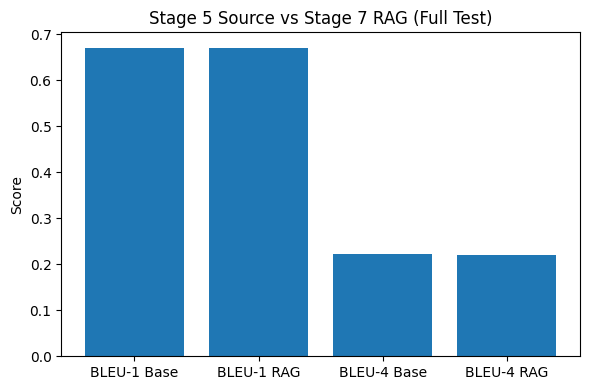

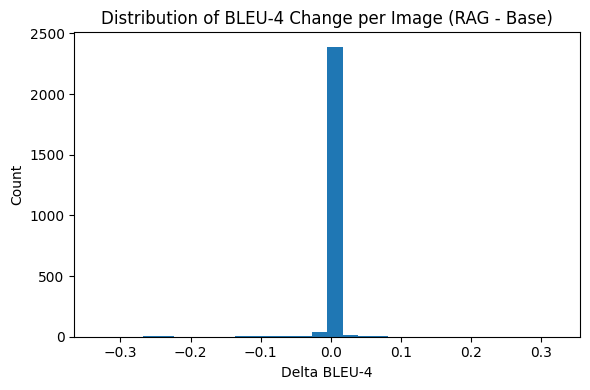

Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/rag_examples.csv
Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/chart_stage5_vs_stage7_bleu.png
Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7/chart_delta_bleu4_hist.png


,image_name,base_caption,retrieved_caption_top1,rag_caption,bleu4_base,bleu4_rag,delta_bleu4
0,000000289594.jpg,a man is walking down the street with a cell p...,a woman walking down the street with a cell phone,a man is walking down the street with a cell p...,0.131938,0.131938,0.000000
1,000000289659.jpg,a giraffe standing next to a tree in a field,a tall giraffe standing next to a tree in a field,a giraffe standing next to a tree in a field,0.137471,0.137471,0.000000
2,000000289702.jpg,a dog is sitting on a table with a bottle of wine,a dog sitting on a couch with a bottle of wine,a dog sitting on a couch with a bottle of wine,0.252119,0.064841,-0.187278
3,000000289741.jpg,a group of people sitting on a beach with a la...,a group of people sitting on beach with variou...,a group of people sitting on a beach with a la...,0.049269,0.049269,0.000000
4,000000289938.jpg,a large group of people are standing outside,a large group of people are standing on the beach,a large group of people are standing on the beach,0.036556,0.053077,0.016522
5,000000289960.jpg,a man flying a kite on a beach,a man flying a kite on a beach,a man flying a kite on a beach,0.208910,0.208910,0.000000
6,000000289992.jpg,a bathroom with a sink and a mirror,a bathroom with a sink and a mirror,a bathroom with a sink and a mirror,0.840896,0.840896,0.000000
7,000000290081.jpg,a bowl of oranges on a table with a glass of o...,a bowl of oranges on a table with a glass,a bowl of oranges on a table with a glass of o...,0.062981,0.062981,0.000000
8,000000290163.jpg,a young boy sitting at a table with a plate of...,a young boy sitting at a table with a plate of...,a young boy sitting at a table with a plate of...,0.262025,0.262025,0.000000
9,000000290179.jpg,a large building with a clock on the top of it,a building with a clock on the top of it,a large building with a clock on the top of it,0.287354,0.287354,0.000000


In [10]:
# Cell 9 — Qualitative analysis + charts
analysis_df = full_df.copy()
analysis_df["bleu4_base"] = analysis_df.apply(lambda r: row_bleu4(r["base_caption"], r["image_name"], refs_map), axis=1)
analysis_df["bleu4_rag"] = analysis_df.apply(lambda r: row_bleu4(r["rag_caption"], r["image_name"], refs_map), axis=1)
analysis_df["delta_bleu4"] = analysis_df["bleu4_rag"] - analysis_df["bleu4_base"]

top_gain = analysis_df.sort_values("delta_bleu4", ascending=False).head(20)
top_drop = analysis_df.sort_values("delta_bleu4", ascending=True).head(20)

examples_path = STAGE7_DIR / "rag_examples.csv"
pd.concat([
    top_gain.assign(category="improved"),
    top_drop.assign(category="worsened")
], ignore_index=True).to_csv(examples_path, index=False)

# Chart: BLEU comparison (full split)
full_row = scores_df[scores_df["split"] == "full"].iloc[0]
plt.figure(figsize=(6,4))
plt.bar(["BLEU-1 Base", "BLEU-1 RAG", "BLEU-4 Base", "BLEU-4 RAG"],
        [full_row["base_bleu1"], full_row["rag_bleu1"], full_row["base_bleu4"], full_row["rag_bleu4"]])
plt.title("Stage 5 Source vs Stage 7 RAG (Full Test)")
plt.ylabel("Score")
plt.tight_layout()
chart1 = STAGE7_DIR / "chart_stage5_vs_stage7_bleu.png"
plt.savefig(chart1, dpi=180)
plt.show()

# Chart: delta BLEU-4 distribution
plt.figure(figsize=(6,4))
plt.hist(analysis_df["delta_bleu4"].dropna(), bins=30)
plt.title("Distribution of BLEU-4 Change per Image (RAG - Base)")
plt.xlabel("Delta BLEU-4")
plt.ylabel("Count")
plt.tight_layout()
chart2 = STAGE7_DIR / "chart_delta_bleu4_hist.png"
plt.savefig(chart2, dpi=180)
plt.show()

print("Saved:", examples_path)
print("Saved:", chart1)
print("Saved:", chart2)
analysis_df[["image_name","base_caption","retrieved_caption_top1","rag_caption","bleu4_base","bleu4_rag","delta_bleu4"]].head(10)


In [11]:
# Cell 10 — Gate check
required = [
    STAGE7_DIR / "retrieval_candidates_topk.csv",
    STAGE7_DIR / "rag_threshold_sweep.csv",
    STAGE7_DIR / "stage5_vs_stage7_comparison.csv",
    STAGE7_DIR / "rag_predictions.csv",
    STAGE7_DIR / "rag_examples.csv",
    STAGE7_DIR / "metrics.json",
    STAGE7_DIR / "chart_stage5_vs_stage7_bleu.png",
    STAGE7_DIR / "chart_delta_bleu4_hist.png",
]
for p in required:
    assert p.exists(), f"Missing: {p}"

print("STAGE 7 PASS")
print("Artifacts in:", STAGE7_DIR)


STAGE 7 PASS
Artifacts in: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage7
